# **EV Demand Forecasting Chatbot Notebook**

### **BUSA 720 - Managerial Decision Modelling | Avni Patel**

•	**Dataset Name:** Electric Vehicle Population Size History by County

•	**Source:** Data.gov

•	**Link:** https://catalog.data.gov/dataset/electric-vehicle-population-size-history-by-county

### **Description:**
This dataset provides monthly electric vehicle (EV) registration counts by county, including both passenger vehicles and trucks. It is compiled by the Washington State Department of Licensing using official registration records along with supporting data from agencies like NHTSA and EPA.

### **Target Variable (What is Forecasted)**
•	**Target Variabel:** Total number of EVs (monthly registrations by county)

•	**Forecast Type:** Time-Series Forecasting (monthly EV population growth)



**This notebook builds an end-to-end electric vehicle demand forecasting chatbot that can:**

• load and clean EV population history data

• aggregate county-level EV data into state-level monthly time series

• forecast EV demand by U.S. state

• compare EV adoption across multiple states

• analyze BEV vs PHEV trends

• calculate EV market share and forecast growth

• backtest multiple time-series forecasting models

• generate forecast tables with future dates

• create forecast charts and model diagnostics

• identify top counties by EV demand

• produce a generative-AI forecast summary and business recommendation

• run in an interactive Gradio forecasting chatbot interface


### **Models included**

• Naive baseline

• ARIMA

• Prophet

• ETS / Exponential Smoothing

• Random Forest on lag features

• Simple ensemble average


### **Forecasting features**

• EV total demand forecast

• BEV demand forecast

• PHEV demand forecast

• EV market share forecast

• State comparison forecast

• County-level EV demand ranking

• Forecast risk classification

• Demand growth category


### **Chatbot questions supported**

• What is the EV demand outlook for Washington?

• Compare WA and CA for the next 24 months

• Which state has the strongest EV growth potential?

• Which state has the highest EV market share?

• Which counties lead EV demand in Washington?

• Compare BEV and PHEV demand in California

• Which model performed best and why?

• What does forecast risk mean?

• Which state needs more charging infrastructure?

• What does the forecast imply for infrastructure planning?


### **Notebook goal**

This notebook is designed for EV demand forecasting, state-level adoption analysis, infrastructure planning, and data-driven policy or business decision support.

## **INSTALL REQUIRED LIBRARIES**

In [ ]:
%pip install -q prophet statsmodels scikit-learn openai matplotlib pandas numpy gradio

In [ ]:
import os
import re
import json
import math
import base64
import warnings
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from openai import OpenAI
import gradio as gr

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## **LOAD DATASET**

In [ ]:
df = pd.read_csv("Electric_Vehicle_Population_Size_History_By_County.csv")
df.head()

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles
0,January 31 2019,Mason,WA,Passenger,108,112,220,46616,46836,0.47
1,May 31 2021,New Haven,CT,Passenger,1,0,1,35,36,2.78
2,January 31 2017,Tarrant,TX,Passenger,0,2,2,342,344,0.58
3,December 31 2022,St. Mary's,MD,Passenger,2,0,2,208,210,0.95
4,February 29 2024,Palm Beach,FL,Passenger,3,0,3,60,63,4.76


## **OPENAI API SETUP**

In [ ]:
# ============================================================
# 4. OPTIONAL OPENAI API SETUP
# ============================================================

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")

if not os.getenv("OPENAI_API_KEY"):
    try:
        entered_key = getpass("Enter OPENAI_API_KEY, press Enter to skip: ").strip()
        if entered_key:
            os.environ["OPENAI_API_KEY"] = entered_key
    except Exception:
        pass


def get_openai_client():
    api_key = os.getenv("OPENAI_API_KEY")

    if not api_key:
        return None

    try:
        return OpenAI(api_key=api_key)
    except Exception:
        return None


client = get_openai_client()
print("OpenAI client ready." if client else "OpenAI client not configured. Using fallback chatbot.")

Enter OPENAI_API_KEY, press Enter to skip: ··········
OpenAI client ready.


## **DATA CLEANING**

In [ ]:
VALID_US_STATE_CODES = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA",
    "KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT",
    "VA","WA","WV","WI","WY","DC"
}

STATE_NAME_TO_CODE = {
    "ALABAMA": "AL", "ALASKA": "AK", "ARIZONA": "AZ", "ARKANSAS": "AR",
    "CALIFORNIA": "CA", "COLORADO": "CO", "CONNECTICUT": "CT", "DELAWARE": "DE",
    "FLORIDA": "FL", "GEORGIA": "GA", "HAWAII": "HI", "IDAHO": "ID",
    "ILLINOIS": "IL", "INDIANA": "IN", "IOWA": "IA", "KANSAS": "KS",
    "KENTUCKY": "KY", "LOUISIANA": "LA", "MAINE": "ME", "MARYLAND": "MD",
    "MASSACHUSETTS": "MA", "MICHIGAN": "MI", "MINNESOTA": "MN", "MISSISSIPPI": "MS",
    "MISSOURI": "MO", "MONTANA": "MT", "NEBRASKA": "NE", "NEVADA": "NV",
    "NEW HAMPSHIRE": "NH", "NEW JERSEY": "NJ", "NEW MEXICO": "NM", "NEW YORK": "NY",
    "NORTH CAROLINA": "NC", "NORTH DAKOTA": "ND", "OHIO": "OH", "OKLAHOMA": "OK",
    "OREGON": "OR", "PENNSYLVANIA": "PA", "RHODE ISLAND": "RI",
    "SOUTH CAROLINA": "SC", "SOUTH DAKOTA": "SD", "TENNESSEE": "TN",
    "TEXAS": "TX", "UTAH": "UT", "VERMONT": "VT", "VIRGINIA": "VA",
    "WASHINGTON": "WA", "WEST VIRGINIA": "WV", "WISCONSIN": "WI",
    "WYOMING": "WY", "DISTRICT OF COLUMBIA": "DC"
}


def clean_ev_dataset(df):
    data = df.copy()
    data.columns = data.columns.str.strip()

    data = data.rename(columns={
        "Battery Electric Vehicles (BEVs)": "Battery Electric Vehicles",
        "Plug-In Hybrid Electric Vehicles (PHEVs)": "Plug-In Hybrid Electric Vehicles"
    })

    required_cols = [
        "Date",
        "County",
        "State",
        "Battery Electric Vehicles",
        "Plug-In Hybrid Electric Vehicles",
        "Electric Vehicle (EV) Total",
        "Non-Electric Vehicle Total",
        "Total Vehicles",
        "Percent Electric Vehicles"
    ]

    missing = [col for col in required_cols if col not in data.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

    numeric_cols = [
        "Battery Electric Vehicles",
        "Plug-In Hybrid Electric Vehicles",
        "Electric Vehicle (EV) Total",
        "Non-Electric Vehicle Total",
        "Total Vehicles",
        "Percent Electric Vehicles"
    ]

    for col in numeric_cols:
        data[col] = (
            data[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
        )
        data[col] = pd.to_numeric(data[col], errors="coerce")

    data["State"] = data["State"].astype(str).str.upper().str.strip()
    data["County"] = data["County"].astype(str).str.title().str.strip()

    data = data[data["State"].isin(VALID_US_STATE_CODES)]
    data = data.dropna(subset=["Date", "State", "Electric Vehicle (EV) Total"])

    return data


ev_df = clean_ev_dataset(df)
state_list = sorted(ev_df["State"].dropna().unique().tolist())
state_list

['AK',
 'AL',
 'AR',
 'AZ',
 'CA',
 'CO',
 'CT',
 'DC',
 'DE',
 'FL',
 'GA',
 'HI',
 'IA',
 'ID',
 'IL',
 'IN',
 'KS',
 'KY',
 'LA',
 'MA',
 'MD',
 'ME',
 'MI',
 'MN',
 'MO',
 'MS',
 'MT',
 'NC',
 'ND',
 'NE',
 'NH',
 'NJ',
 'NM',
 'NV',
 'NY',
 'OH',
 'OK',
 'OR',
 'PA',
 'RI',
 'SC',
 'SD',
 'TN',
 'TX',
 'UT',
 'VA',
 'WA',
 'WI',
 'WY']

## **CREATE MONTHLY STATE-LEVEL TIME SERIES**

In [ ]:
def prepare_state_monthly_data(df, state="WA"):
    data = clean_ev_dataset(df)
    state = state.upper()

    state_data = data[data["State"] == state].copy()

    if state_data.empty:
        raise ValueError(f"No data found for state: {state}")

    monthly = (
        state_data
        .groupby("Date")
        .agg({
            "Battery Electric Vehicles": "sum",
            "Plug-In Hybrid Electric Vehicles": "sum",
            "Electric Vehicle (EV) Total": "sum",
            "Non-Electric Vehicle Total": "sum",
            "Total Vehicles": "sum"
        })
        .reset_index()
        .sort_values("Date")
    )

    monthly = monthly.rename(columns={
        "Battery Electric Vehicles": "BEV_Total",
        "Plug-In Hybrid Electric Vehicles": "PHEV_Total",
        "Electric Vehicle (EV) Total": "EV_Total",
        "Non-Electric Vehicle Total": "Non_EV_Total",
        "Total Vehicles": "Total_Vehicles"
    })

    monthly = monthly.set_index("Date").resample("M").sum()

    monthly = (
        monthly
        .replace([np.inf, -np.inf], np.nan)
        .interpolate()
        .ffill()
        .bfill()
        .fillna(0)
    )

    monthly["EV_Market_Share"] = np.where(
        monthly["Total_Vehicles"] > 0,
        (monthly["EV_Total"] / monthly["Total_Vehicles"]) * 100,
        0
    )

    monthly["EV_Growth_Rate"] = (
        monthly["EV_Total"]
        .pct_change()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    monthly["BEV_Share"] = np.where(
        monthly["EV_Total"] > 0,
        monthly["BEV_Total"] / monthly["EV_Total"],
        0
    )

    monthly["PHEV_Share"] = np.where(
        monthly["EV_Total"] > 0,
        monthly["PHEV_Total"] / monthly["EV_Total"],
        0
    )

    monthly["EV_Rolling_3M"] = monthly["EV_Total"].rolling(3).mean()
    monthly["EV_Rolling_6M"] = monthly["EV_Total"].rolling(6).mean()
    monthly["EV_Momentum_3M"] = monthly["EV_Total"].pct_change(3)
    monthly["EV_Momentum_6M"] = monthly["EV_Total"].pct_change(6)

    monthly = (
        monthly
        .replace([np.inf, -np.inf], np.nan)
        .ffill()
        .bfill()
        .fillna(0)
    )

    return monthly

## **TIME SERIES HELPER FUNCTIONS**

In [ ]:
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def make_future_month_index(last_date, periods):
    return pd.date_range(
        start=last_date + pd.offsets.MonthEnd(1),
        periods=int(periods),
        freq="M"
    )


def format_forecast_table(forecast_df):
    display_df = forecast_df.copy()
    display_df.index = pd.to_datetime(display_df.index)
    display_df = display_df.reset_index()
    display_df = display_df.rename(columns={"index": "Date"})
    display_df["Date"] = display_df["Date"].dt.strftime("%Y-%m-%d")
    return display_df

# **FORECASTING MODELS**

In [ ]:
# MODEL 1: NAIVE BASELINE
# ============================================================

def naive_forecast(train_series, steps):
    future_index = make_future_month_index(train_series.index[-1], steps)
    forecast_values = [train_series.iloc[-1]] * int(steps)
    return pd.Series(forecast_values, index=future_index)

In [ ]:
# MODEL 2: ARIMA
# ============================================================

def select_arima_order(train_series, candidate_orders=None):
    if candidate_orders is None:
        candidate_orders = [
            (0, 1, 0),
            (1, 1, 0),
            (0, 1, 1),
            (1, 1, 1),
            (2, 1, 1),
            (2, 1, 2),
            (3, 1, 2)
        ]

    best_model = None
    best_order = None
    best_aic = np.inf

    train_series = (
        pd.to_numeric(train_series, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    for order in candidate_orders:
        try:
            model = ARIMA(train_series, order=order).fit()

            if model.aic < best_aic:
                best_model = model
                best_order = order
                best_aic = model.aic

        except Exception:
            continue

    if best_model is None:
        raise RuntimeError("ARIMA failed for all candidate orders.")

    return best_model, best_order


def arima_forecast(train_series, steps):
    model, order = select_arima_order(train_series)
    pred = model.forecast(steps=int(steps))
    pred.index = make_future_month_index(train_series.index[-1], steps)
    return pred.clip(lower=0), order

In [ ]:
# MODEL 3: PROPHET
# ============================================================

def prophet_forecast(train_series, steps):
    prophet_df = train_series.reset_index()
    prophet_df.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )

    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=int(steps), freq="M")
    forecast = model.predict(future)

    pred = forecast.set_index("ds")["yhat"].tail(int(steps))
    pred.index = make_future_month_index(train_series.index[-1], steps)

    return pred.clip(lower=0)

In [ ]:
# MODEL 4: ETS EXPONENTIAL SMOOTHING
# ============================================================

def ets_forecast(train_series, steps):
    train_series = (
        pd.to_numeric(train_series, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    seasonal = "add" if len(train_series) >= 36 else None
    seasonal_periods = 12 if seasonal else None

    model = ExponentialSmoothing(
        train_series,
        trend="add",
        seasonal=seasonal,
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    ).fit(optimized=True)

    pred = model.forecast(int(steps))
    pred.index = make_future_month_index(train_series.index[-1], steps)

    return pred.clip(lower=0)

In [ ]:
# MODEL 5: RANDOM FOREST LAG MODEL
# ============================================================

def make_lag_features(series, lags=(1, 2, 3, 6, 12)):
    data = pd.DataFrame({"y": series})

    for lag in lags:
        data[f"lag_{lag}"] = series.shift(lag)

    data["rolling_mean_3"] = series.shift(1).rolling(3).mean()
    data["rolling_mean_6"] = series.shift(1).rolling(6).mean()
    data["rolling_std_3"] = series.shift(1).rolling(3).std()
    data["growth_1"] = series.pct_change(1).shift(1)
    data["growth_3"] = series.pct_change(3).shift(1)

    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    return data


def random_forest_forecast(series, steps):
    lag_df = make_lag_features(series)

    if lag_df.empty:
        raise ValueError("Not enough data for Random Forest forecasting.")

    X = lag_df.drop(columns="y")
    y = lag_df["y"]

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X, y)

    history = series.tolist()
    preds = []

    for _ in range(int(steps)):
        temp = pd.Series(history)

        row = pd.DataFrame({
            "lag_1": [temp.iloc[-1]],
            "lag_2": [temp.iloc[-2]],
            "lag_3": [temp.iloc[-3]],
            "lag_6": [temp.iloc[-6]],
            "lag_12": [temp.iloc[-12]],
            "rolling_mean_3": [temp.iloc[-3:].mean()],
            "rolling_mean_6": [temp.iloc[-6:].mean()],
            "rolling_std_3": [temp.iloc[-3:].std()],
            "growth_1": [temp.iloc[-1] / temp.iloc[-2] - 1 if temp.iloc[-2] != 0 else 0],
            "growth_3": [temp.iloc[-1] / temp.iloc[-4] - 1 if temp.iloc[-4] != 0 else 0],
        })

        row = row.replace([np.inf, -np.inf], np.nan).fillna(0)

        pred = max(float(model.predict(row)[0]), 0)
        preds.append(pred)
        history.append(pred)

    future_index = make_future_month_index(series.index[-1], steps)

    return pd.Series(preds, index=future_index)

In [ ]:
# ============================================================
# BACKTESTING
# ============================================================

def backtest_models(series, test_periods=12):
    series = (
        pd.to_numeric(series, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(series) < test_periods + 18:
        raise ValueError("Not enough monthly data for stable forecasting.")

    train = series.iloc[:-test_periods]
    test = series.iloc[-test_periods:]
    pred_index = test.index

    predictions = {}
    predictions["Naive"] = pd.Series([train.iloc[-1]] * test_periods, index=pred_index)

    try:
        arima_pred, arima_order = arima_forecast(train, test_periods)
        arima_pred.index = pred_index
        predictions[f"ARIMA{arima_order}"] = arima_pred
    except Exception as e:
        print(f"ARIMA skipped: {e}")

    try:
        prophet_pred = prophet_forecast(train, test_periods)
        prophet_pred.index = pred_index
        predictions["Prophet"] = prophet_pred
    except Exception as e:
        print(f"Prophet skipped: {e}")

    try:
        ets_pred = ets_forecast(train, test_periods)
        ets_pred.index = pred_index
        predictions["ETS"] = ets_pred
    except Exception as e:
        print(f"ETS skipped: {e}")

    try:
        rf_pred = random_forest_forecast(train, test_periods)
        rf_pred.index = pred_index
        predictions["Random Forest Lag"] = rf_pred
    except Exception as e:
        print(f"Random Forest skipped: {e}")

    pred_df = pd.concat(predictions.values(), axis=1)
    pred_df.columns = list(predictions.keys())

    model_cols = [col for col in pred_df.columns if col != "Naive"]
    pred_df["Ensemble"] = pred_df[model_cols].mean(axis=1)

    metrics = []

    for col in pred_df.columns:
        aligned = pd.concat(
            [test.rename("Actual"), pred_df[col].rename("Predicted")],
            axis=1
        ).dropna()

        metrics.append({
            "Model": col,
            "RMSE": rmse(aligned["Actual"], aligned["Predicted"]),
            "MAE": mean_absolute_error(aligned["Actual"], aligned["Predicted"]),
            "MAPE": mean_absolute_percentage_error(aligned["Actual"], aligned["Predicted"])
        })

    metrics_df = pd.DataFrame(metrics).sort_values("RMSE").reset_index(drop=True)

    return test, pred_df, metrics_df

In [ ]:
# ============================================================
# FUTURE FORECASTING BY HORIZON
# ============================================================

def future_forecasts(series, horizon=12):
    series = (
        pd.to_numeric(series, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    forecasts = {}
    forecasts["Naive"] = naive_forecast(series, horizon)

    try:
        arima_pred, arima_order = arima_forecast(series, horizon)
        forecasts[f"ARIMA{arima_order}"] = arima_pred
    except Exception as e:
        print(f"ARIMA future skipped: {e}")

    try:
        forecasts["Prophet"] = prophet_forecast(series, horizon)
    except Exception as e:
        print(f"Prophet future skipped: {e}")

    try:
        forecasts["ETS"] = ets_forecast(series, horizon)
    except Exception as e:
        print(f"ETS future skipped: {e}")

    try:
        forecasts["Random Forest Lag"] = random_forest_forecast(series, horizon)
    except Exception as e:
        print(f"Random Forest future skipped: {e}")

    forecast_df = pd.concat(forecasts.values(), axis=1)
    forecast_df.columns = list(forecasts.keys())

    model_cols = [col for col in forecast_df.columns if col != "Naive"]
    forecast_df["Ensemble"] = forecast_df[model_cols].mean(axis=1)

    return forecast_df

## **STATE FORECAST ENGINE**

In [ ]:
def forecast_target(series, horizon=12, test_periods=12):
    test, pred_df, metrics_df = backtest_models(series, test_periods=test_periods)
    forecast_df = future_forecasts(series, horizon=horizon)

    return {
        "test": test,
        "predictions": pred_df,
        "metrics": metrics_df,
        "forecast": forecast_df,
        "forecast_display": format_forecast_table(forecast_df)
    }


def get_top_counties_by_ev(state="WA", top_n=10):
    data = clean_ev_dataset(df)

    state = state.upper()
    latest_date = data["Date"].max()

    latest_state = data[
        (data["State"] == state) &
        (data["Date"] == latest_date)
    ]

    county_rank = (
        latest_state
        .groupby("County")["Electric Vehicle (EV) Total"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    county_rank.columns = ["County", "EV Total"]

    return county_rank


def advanced_state_forecast(state="WA", horizon=12, test_periods=12):
    state = state.upper()
    data = prepare_state_monthly_data(df, state)

    targets = {
        "EV_Total": "Total EV Demand",
        "BEV_Total": "Battery Electric Vehicle Demand",
        "PHEV_Total": "Plug-In Hybrid Demand",
        "EV_Market_Share": "EV Market Share"
    }

    forecast_results = {}

    for target, label in targets.items():
        try:
            forecast_results[target] = forecast_target(
                data[target],
                horizon=horizon,
                test_periods=test_periods
            )

            forecast_results[target]["label"] = label

        except Exception as e:
            print(f"{target} skipped: {e}")

    if "EV_Total" not in forecast_results:
        raise ValueError("EV_Total forecast failed. Try another state with more history.")

    latest_ev = data["EV_Total"].iloc[-1]
    final_ev = forecast_results["EV_Total"]["forecast"]["Ensemble"].iloc[-1]
    growth_rate = (final_ev / latest_ev) - 1 if latest_ev != 0 else 0

    best_model = forecast_results["EV_Total"]["metrics"].iloc[0]["Model"]
    best_rmse = forecast_results["EV_Total"]["metrics"].iloc[0]["RMSE"]

    risk_ratio = best_rmse / latest_ev if latest_ev != 0 else 1

    demand_category = (
        "High Growth Demand" if growth_rate >= 0.15 else
        "Moderate Growth Demand" if growth_rate >= 0.05 else
        "Stable Demand" if growth_rate >= 0 else
        "Declining or Weak Demand"
    )

    forecast_risk = (
        "Low Forecast Risk" if risk_ratio < 0.05 else
        "Medium Forecast Risk" if risk_ratio < 0.15 else
        "High Forecast Risk"
    )

    compact = {
        "state": state,
        "latest_date": str(data.index[-1].date()),
        "forecast_horizon_months": int(horizon),
        "latest_ev_total": float(latest_ev),
        "forecasted_ev_total": float(final_ev),
        "forecast_growth_rate": float(growth_rate),
        "latest_ev_market_share_percent": float(data["EV_Market_Share"].iloc[-1]),
        "bev_latest_total": float(data["BEV_Total"].iloc[-1]),
        "phev_latest_total": float(data["PHEV_Total"].iloc[-1]),
        "bev_share_percent": float(data["BEV_Share"].iloc[-1] * 100),
        "phev_share_percent": float(data["PHEV_Share"].iloc[-1] * 100),
        "best_model": best_model,
        "best_rmse": float(best_rmse),
        "demand_category": demand_category,
        "forecast_risk": forecast_risk
    }

    county_rank = get_top_counties_by_ev(state, top_n=10)

    return {
        "state": state,
        "data": data,
        "forecast_results": forecast_results,
        "compact": compact,
        "top_counties": county_rank
    }

In [ ]:
# ============================================================
# AI SUMMARY
# ============================================================

def fallback_ev_summary(compact, county_rank=None):
    county_text = "County data not available."

    if county_rank is not None and not county_rank.empty:
        county_text = f"{county_rank.iloc[0]['County']} leads with {county_rank.iloc[0]['EV Total']:.0f} EVs."

    return f"""
Advanced EV Demand Forecast Summary for {compact['state']}

1. Demand Outlook
- Latest EV total: {compact['latest_ev_total']:.0f}
- Forecasted EV total after {compact['forecast_horizon_months']} months: {compact['forecasted_ev_total']:.0f}
- Forecasted growth rate: {compact['forecast_growth_rate']:.2%}
- Demand category: {compact['demand_category']}

2. EV Mix
- Latest BEV total: {compact['bev_latest_total']:.0f}
- Latest PHEV total: {compact['phev_latest_total']:.0f}
- BEV share: {compact['bev_share_percent']:.2f}%
- PHEV share: {compact['phev_share_percent']:.2f}%

3. Market Share
- Latest EV market share: {compact['latest_ev_market_share_percent']:.2f}%

4. Model Performance
- Best model: {compact['best_model']}
- Best RMSE: {compact['best_rmse']:.2f}
- Forecast risk: {compact['forecast_risk']}

5. County Insight
- {county_text}
"""


def generate_ev_llm_summary(compact, county_rank=None):
    if client is None:
        return fallback_ev_summary(compact, county_rank)

    county_data = county_rank.to_dict(orient="records") if county_rank is not None else []

    prompt = f"""
You are an advanced EV time-series forecasting analyst.

Use only this forecast output:

State forecast:
{json.dumps(compact, indent=2)}

Top counties:
{json.dumps(county_data, indent=2)}

Write a professional summary explaining:
1. EV demand outlook
2. Forecast horizon
3. Model accuracy
4. Demand risk
5. BEV vs PHEV mix
6. EV market share
7. County concentration
8. Infrastructure planning implication
"""

    try:
        response = client.responses.create(
            model=OPENAI_MODEL,
            input=prompt
        )

        return response.output_text

    except Exception:
        return fallback_ev_summary(compact, county_rank)


LAST_RESULTS = {}


def analyze_ev_state(state="WA", horizon=12, test_periods=12):
    result = advanced_state_forecast(
        state=state,
        horizon=horizon,
        test_periods=test_periods
    )

    result["summary"] = generate_ev_llm_summary(
        result["compact"],
        result["top_counties"]
    )

    LAST_RESULTS[state.upper()] = result

    return result

In [ ]:
# ============================================================
# PLOTS
# ============================================================

def create_forecast_plot(result):
    data = result["data"]
    forecast_df = result["forecast_results"]["EV_Total"]["forecast"]
    state = result["state"]

    fig, ax = plt.subplots(figsize=(13, 5))
    recent_history = data["EV_Total"].tail(36)

    ax.plot(
        recent_history.index,
        recent_history.values,
        label="Historical EV Total",
        linewidth=2
    )

    for col in forecast_df.columns:
        ax.plot(
            forecast_df.index,
            forecast_df[col],
            label=col
        )

    ax.set_title(f"Forward EV Demand Forecast - {state}")
    ax.set_xlabel("Date")
    ax.set_ylabel("EV Total")
    ax.legend()
    ax.grid(True)

    return fig


def create_backtest_plot(result):
    test = result["forecast_results"]["EV_Total"]["test"]
    pred_df = result["forecast_results"]["EV_Total"]["predictions"]
    state = result["state"]

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(test.index, test.values, label="Actual", linewidth=2)

    for col in pred_df.columns:
        ax.plot(pred_df.index, pred_df[col], label=col)

    ax.set_title(f"Backtest: Actual vs Predicted - {state}")
    ax.set_xlabel("Date")
    ax.set_ylabel("EV Total")
    ax.legend()
    ax.grid(True)

    return fig


def create_bev_phev_plot(result):
    data = result["data"]
    state = result["state"]

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(data.index, data["BEV_Total"], label="BEV Total", linewidth=2)
    ax.plot(data.index, data["PHEV_Total"], label="PHEV Total", linewidth=2)

    ax.set_title(f"BEV vs PHEV Demand Trend - {state}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Vehicle Count")
    ax.legend()
    ax.grid(True)

    return fig


def create_market_share_plot(result):
    data = result["data"]
    forecast_df = result["forecast_results"].get("EV_Market_Share", {}).get("forecast", pd.DataFrame())
    state = result["state"]

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(
        data.index,
        data["EV_Market_Share"],
        label="Historical EV Market Share %",
        linewidth=2
    )

    if not forecast_df.empty and "Ensemble" in forecast_df.columns:
        ax.plot(
            forecast_df.index,
            forecast_df["Ensemble"],
            label="Forecast EV Market Share %",
            linewidth=2
        )

    ax.set_title(f"EV Market Share Forecast - {state}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Market Share (%)")
    ax.legend()
    ax.grid(True)

    return fig


def create_county_plot(result):
    county_rank = result["top_counties"]
    state = result["state"]

    fig, ax = plt.subplots(figsize=(13, 5))

    if county_rank.empty:
        ax.text(0.5, 0.5, "No county data available", ha="center", va="center")
    else:
        ax.bar(county_rank["County"], county_rank["EV Total"])
        ax.tick_params(axis="x", rotation=45)

    ax.set_title(f"Top Counties by EV Demand - {state}")
    ax.set_xlabel("County")
    ax.set_ylabel("EV Total")
    ax.grid(True)

    return fig

## **COMPARISON + OPEN-QUERY CHATBOT**

In [ ]:
def compare_states(states, horizon=12):
    rows = []

    for state in states:
        try:
            result = analyze_ev_state(
                state=state,
                horizon=horizon,
                test_periods=12
            )

            c = result["compact"]

            rows.append({
                "State": c["state"],
                "Latest EV Total": c["latest_ev_total"],
                f"Forecasted EV Total after {horizon} Months": c["forecasted_ev_total"],
                "Forecast Growth Rate": c["forecast_growth_rate"],
                "EV Market Share %": c["latest_ev_market_share_percent"],
                "BEV Share %": c["bev_share_percent"],
                "PHEV Share %": c["phev_share_percent"],
                "Demand Category": c["demand_category"],
                "Forecast Risk": c["forecast_risk"],
                "Best Model": c["best_model"],
                "Best RMSE": c["best_rmse"]
            })

        except Exception as e:
            print(f"{state} skipped: {e}")

    return pd.DataFrame(rows)


def create_comparison_plot(comparison_df):
    fig, ax = plt.subplots(figsize=(13, 5))

    if comparison_df.empty:
        ax.text(0.5, 0.5, "No comparison data available", ha="center", va="center")
    else:
        ax.bar(
            comparison_df["State"],
            comparison_df["Forecast Growth Rate"]
        )

    ax.set_title("State-Wise EV Forecast Growth Rate")
    ax.set_xlabel("State")
    ax.set_ylabel("Forecast Growth Rate")
    ax.grid(True)

    return fig


def extract_states_from_question(question):
    q = question.upper()
    found = []

    for name, code in STATE_NAME_TO_CODE.items():
        if re.search(r"\b" + re.escape(name) + r"\b", q):
            found.append(code)

    for state in state_list:
        if re.search(r"\b" + re.escape(state) + r"\b", q):
            found.append(state)

    return sorted(list(set(found)))


def get_default_analysis_states(question, max_states=10):
    q = question.lower()

    broad_terms = [
        "which state",
        "best state",
        "highest",
        "lowest",
        "rank",
        "ranking",
        "top",
        "compare states",
        "all states",
        "market share",
        "growth",
        "risk",
        "infrastructure",
        "charging",
        "demand quality"
    ]

    if any(term in q for term in broad_terms):
        latest_top_states = (
            ev_df[ev_df["Date"] == ev_df["Date"].max()]
            .groupby("State")["Electric Vehicle (EV) Total"]
            .sum()
            .sort_values(ascending=False)
            .head(max_states)
            .index
            .tolist()
        )

        return latest_top_states

    if LAST_RESULTS:
        return list(LAST_RESULTS.keys())

    return ["WA", "CA", "NY", "FL", "TX"]


def explain_models():
    return """
Time-Series Model Explanation

1. ARIMA
- A statistical time-series model.
- Captures trend and autocorrelation.
- Good for structured monthly time-series patterns.

2. Prophet
- A time-series forecasting model from Meta.
- Captures trend and seasonality.
- Good for adoption-growth behavior.

3. ETS / Exponential Smoothing
- A true time-series model.
- Captures level, trend, and seasonality.
- Good when recent trend matters strongly.

4. Random Forest Lag
- Machine learning model using time-series lag features.
- Uses previous months, rolling averages, volatility, and growth momentum.
- Good for nonlinear EV adoption patterns.

5. Ensemble
- Combines ARIMA, Prophet, ETS, and Random Forest.
- Reduces single-model bias.
"""


def advanced_chatbot_response(question, horizon=12):
    detected_states = extract_states_from_question(question)

    if not detected_states:
        detected_states = get_default_analysis_states(question)

    for state in detected_states:
        if state not in LAST_RESULTS or LAST_RESULTS[state]["compact"]["forecast_horizon_months"] != int(horizon):
            try:
                analyze_ev_state(
                    state=state,
                    horizon=int(horizon),
                    test_periods=12
                )
            except Exception as e:
                print(f"Could not analyze {state}: {e}")

    context = {
        state: LAST_RESULTS[state]["compact"]
        for state in detected_states
        if state in LAST_RESULTS
    }

    county_context = {
        state: LAST_RESULTS[state]["top_counties"].to_dict(orient="records")
        for state in detected_states
        if state in LAST_RESULTS
    }

    forecast_context = {
        state: LAST_RESULTS[state]["forecast_results"]["EV_Total"]["forecast_display"].head(6).to_dict(orient="records")
        for state in detected_states
        if state in LAST_RESULTS
    }

    metrics_context = {
        state: LAST_RESULTS[state]["forecast_results"]["EV_Total"]["metrics"].to_dict(orient="records")
        for state in detected_states
        if state in LAST_RESULTS
    }

    if not context:
        return "I could not generate forecast context. Please mention a valid U.S. state like WA, CA, NY, OH, TX, or FL."

    lower_q = question.lower()

    if any(term in lower_q for term in ["arima", "prophet", "ets", "exponential", "random forest", "model", "ensemble"]):
        return explain_models()

    if client is None:
        response = "Advanced EV Forecasting ChatBot Answer\n\n"

        if len(context) > 1:
            best_growth = max(context, key=lambda s: context[s]["forecast_growth_rate"])
            best_market = max(context, key=lambda s: context[s]["latest_ev_market_share_percent"])
            lowest_risk_states = [s for s in context if context[s]["forecast_risk"] == "Low Forecast Risk"]

            response += "Multi-State Insight:\n"
            response += f"- Strongest forecast growth: {best_growth}\n"
            response += f"- Highest current EV market share: {best_market}\n"
            response += f"- Lower-risk states: {', '.join(lowest_risk_states) if lowest_risk_states else 'None in this comparison'}\n\n"

        for state, c in context.items():
            response += f"""
State: {state}
- Latest EV Total: {c['latest_ev_total']:.0f}
- Forecasted EV Total after {c['forecast_horizon_months']} months: {c['forecasted_ev_total']:.0f}
- Forecast Growth Rate: {c['forecast_growth_rate']:.2%}
- EV Market Share: {c['latest_ev_market_share_percent']:.2f}%
- BEV Share: {c['bev_share_percent']:.2f}%
- PHEV Share: {c['phev_share_percent']:.2f}%
- Best Model: {c['best_model']}
- Forecast Risk: {c['forecast_risk']}
- Demand Category: {c['demand_category']}

"""
        return response

    prompt = f"""
You are a senior EV demand forecasting analyst.

The user asked:
{question}

Use ONLY the forecast analytics below.

Forecast horizon:
{horizon} months

State forecast summary:
{json.dumps(context, indent=2)}

Forward forecast tables with dates:
{json.dumps(forecast_context, indent=2)}

Model accuracy metrics:
{json.dumps(metrics_context, indent=2)}

County context:
{json.dumps(county_context, indent=2)}

Answer requirements:
1. Give a pro-level answer, not a generic answer.
2. Use exact values from the forecast context.
3. If comparing states, give winners by demand size, growth, market share, forecast risk, and infrastructure priority.
4. If asked about infrastructure, connect EV total, BEV share, growth, and forecast risk.
5. If asked about demand quality, balance growth against risk.
6. If asked about models, explain which model performed best using RMSE.
7. Do not invent facts outside the provided dataset.
8. End with a practical business recommendation.
"""

    try:
        response = client.responses.create(
            model=OPENAI_MODEL,
            input=prompt
        )

        return response.output_text

    except Exception:
        return json.dumps(context, indent=2)

## **GRADIO FUNCTIONS**

In [ ]:
def gradio_single_state(state, horizon):
    if state is None:
        empty = pd.DataFrame()
        return "Please select a state.", empty, empty, empty, empty, empty, empty, None, None, None, None, None

    try:
        result = analyze_ev_state(
            state=state,
            horizon=int(horizon),
            test_periods=12
        )

        return (
            result["summary"],
            result["forecast_results"]["EV_Total"]["metrics"],
            result["forecast_results"]["EV_Total"]["forecast_display"],
            result["forecast_results"].get("BEV_Total", {}).get("forecast_display", pd.DataFrame()),
            result["forecast_results"].get("PHEV_Total", {}).get("forecast_display", pd.DataFrame()),
            result["forecast_results"].get("EV_Market_Share", {}).get("forecast_display", pd.DataFrame()),
            result["top_counties"],
            create_forecast_plot(result),
            create_backtest_plot(result),
            create_bev_phev_plot(result),
            create_market_share_plot(result),
            create_county_plot(result)
        )

    except Exception as e:
        empty = pd.DataFrame()
        return f"Forecast Error:\n\n{str(e)}", empty, empty, empty, empty, empty, empty, None, None, None, None, None


def gradio_compare(selected_states, horizon):
    if not selected_states:
        return pd.DataFrame({"Message": ["Please select at least one state."]}), None

    comp_df = compare_states(
        selected_states,
        horizon=int(horizon)
    )

    return comp_df, create_comparison_plot(comp_df)


def gradio_chat(message, history, horizon):
    if history is None:
        history = []

    if message is None or str(message).strip() == "":
        return history, ""

    try:
        answer = advanced_chatbot_response(
            str(message).strip(),
            horizon=int(horizon)
        )

    except Exception as e:
        answer = f"ChatBot Error:\n\n{str(e)}"

    history.append({"role": "user", "content": str(message).strip()})
    history.append({"role": "assistant", "content": answer})

    return history, ""


def clear_chat():
    return [], ""


def image_to_base64(path):
    with open(path, "rb") as image_file:
        encoded = base64.b64encode(image_file.read()).decode("utf-8")
    return encoded

## **GRADIO UI**

In [ ]:
advanced_example_questions = """
You can ask any advanced forecasting question. Examples:

- Compare WA and CA for the next 24 months.
- Which state has the strongest EV growth potential?
- Which state has the best demand quality based on growth and risk?
- Which state needs more charging infrastructure?
- What is the EV demand outlook for Ohio?
- Compare BEV and PHEV demand in California.
- Which counties lead EV demand in Washington?
- Which model performed best and why?
- Explain forecast risk in business terms.
- Which state has the highest EV market share?
- Is EV demand accelerating or slowing?
- What does the forecast imply for infrastructure planning?
"""

ev_img_base64 = image_to_base64("ev_background.png")

custom_css = """
#app-container {
    max-width: 1240px;
    margin: auto;
}

#hero {
    background: linear-gradient(110deg, #061b3d 0%, #0a3478 58%, #0b7ecb 100%);
    border-radius: 18px;
    padding: 34px 36px;
    margin-bottom: 26px;
    color: white;
    box-shadow: 0 10px 28px rgba(11, 50, 105, 0.25);
}

#title-text h1,
#title-text p,
#title-text strong {
    color: white !important;
}

#title-text h1 {
    font-size: 34px !important;
    font-weight: 800 !important;
    margin-bottom: 18px !important;
}

#title-text p {
    font-size: 16px !important;
    line-height: 1.7 !important;
}

.hero-img {
    width: 100%;
    height: 230px;
    object-fit: cover;
    object-position: center;
    border-radius: 14px;
    display: block;
    border: none;
    background: transparent;
}

.card {
    background: #ffffff !important;
    border-radius: 16px !important;
    padding: 18px !important;
    border: 1px solid #e6edf5 !important;
    box-shadow: 0 8px 22px rgba(15, 40, 80, 0.08) !important;
    margin-top: 16px;
}

.section-title {
    border-left: 4px solid #315efb;
    padding-left: 12px;
    font-size: 18px;
    font-weight: 800;
    color: #14243b;
}

.primary-button {
    background: linear-gradient(90deg, #3d80e8, #004aad) !important;
    color: white !important;
    border: none !important;
    border-radius: 8px !important;
    font-weight: 800 !important;
    height: 42px;
}
"""

state_list = sorted(ev_df["State"].dropna().unique().tolist())

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
    with gr.Column(elem_id="app-container"):

        with gr.Row(elem_id="hero"):
            with gr.Column(scale=2, elem_id="title-text"):
                gr.Markdown(
                    """
                    # 🚗 EV Demand Forecasting Pro ChatBot

                    State-wise electric vehicle demand forecasting using
                    **ARIMA, Prophet, ETS, Random Forest Lag, and Ensemble Models.**

                    Analyze EV demand, BEV vs PHEV trends, market share, county concentration, and infrastructure planning needs.
                    """
                )

            with gr.Column(scale=1):
                gr.HTML(
                    f"""
                    <img class="hero-img" src="data:image/png;base64,{ev_img_base64}">
                    """
                )

        with gr.Tabs():

            with gr.Tab("Single State Advanced Forecast"):
                with gr.Group(elem_classes="card"):
                    gr.Markdown('<div class="section-title">Advanced Forecast Configuration</div>')

                    with gr.Row():
                        state_dropdown = gr.Dropdown(
                            choices=state_list,
                            value=None,
                            label="Select State"
                        )

                        forecast_horizon = gr.Slider(
                            minimum=3,
                            maximum=36,
                            value=12,
                            step=1,
                            label="Forecast Horizon in Months"
                        )

                    run_btn = gr.Button(
                        "📊 Run Advanced Forecast",
                        elem_classes="primary-button"
                    )

                summary_output = gr.Textbox(
                    label="Advanced AI Demand Forecast Summary",
                    lines=14
                )

                forecast_plot_output = gr.Plot(label="Forward EV Forecast")
                backtest_plot_output = gr.Plot(label="Backtest Graph")
                bev_phev_plot_output = gr.Plot(label="BEV vs PHEV Trend")
                market_share_plot_output = gr.Plot(label="EV Market Share Trend")
                county_plot_output = gr.Plot(label="Top Counties by EV Demand")

                metrics_output = gr.Dataframe(label="Model Backtest Metrics")
                ev_forecast_output = gr.Dataframe(label="EV Total Forward Forecast with Dates")
                bev_output = gr.Dataframe(label="BEV Forecast with Dates")
                phev_output = gr.Dataframe(label="PHEV Forecast with Dates")
                market_share_output = gr.Dataframe(label="EV Market Share Forecast with Dates")
                county_output = gr.Dataframe(label="Top Counties")

                run_btn.click(
                    fn=gradio_single_state,
                    inputs=[state_dropdown, forecast_horizon],
                    outputs=[
                        summary_output,
                        metrics_output,
                        ev_forecast_output,
                        bev_output,
                        phev_output,
                        market_share_output,
                        county_output,
                        forecast_plot_output,
                        backtest_plot_output,
                        bev_phev_plot_output,
                        market_share_plot_output,
                        county_plot_output
                    ]
                )

            with gr.Tab("Compare US States"):
                states_checkbox = gr.CheckboxGroup(
                    choices=state_list,
                    value=[],
                    label="Select States to Compare"
                )

                compare_horizon = gr.Slider(
                    minimum=3,
                    maximum=36,
                    value=12,
                    step=1,
                    label="Comparison Forecast Horizon in Months"
                )

                compare_btn = gr.Button(
                    "📊 Compare Selected States",
                    elem_classes="primary-button"
                )

                comparison_output = gr.Dataframe(label="Advanced State Comparison Table")
                comparison_plot_output = gr.Plot(label="State Forecast Growth Comparison")

                compare_btn.click(
                    fn=gradio_compare,
                    inputs=[states_checkbox, compare_horizon],
                    outputs=[comparison_output, comparison_plot_output]
                )

            with gr.Tab("Forecast ChatBot"):
                with gr.Group(elem_classes="card"):
                    gr.Markdown('<div class="section-title">Advanced Open-Query EV Forecasting ChatBot</div>')

                    gr.Markdown(advanced_example_questions)

                    chat_horizon = gr.Slider(
                        minimum=3,
                        maximum=36,
                        value=12,
                        step=1,
                        label="ChatBot Forecast Horizon in Months"
                    )

                    chatbot = gr.Chatbot(
                        label="EV Forecasting ChatBot",
                        height=430,
                        type="messages"
                    )

                    chat_question = gr.Textbox(
                        label="Ask any EV forecasting question",
                        placeholder="Example: Which state has the best demand quality based on growth and risk?",
                        lines=2
                    )

                    with gr.Row():
                        chat_btn = gr.Button(
                            "Ask ChatBot",
                            elem_classes="primary-button"
                        )

                        clear_btn = gr.Button("Clear Chat")

                    chat_btn.click(
                        fn=gradio_chat,
                        inputs=[chat_question, chatbot, chat_horizon],
                        outputs=[chatbot, chat_question]
                    )

                    clear_btn.click(
                        fn=clear_chat,
                        inputs=None,
                        outputs=[chatbot, chat_question]
                    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0436afe432d63629bd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **NOTEBOOK STARTER FUNCTIONS + COMMAND CHATBOT LOOP**

**UNCOMMENT THE BELOW CELLS FOR CHATBOT IN COLAB ENVIRONMENT**

## **Test commands**

**help**

**analyze WA 18**

**compare WA CA 24**

**topcounties WA**

**marketshare CA**

**trend WA**

**models WA**

**risk WA**

**infrastructure WA**

**ask Which state has the strongest EV growth potential?**

**quit**

In [ ]:
# def analyze_ev_forecast_by_state(state="WA", horizon=18, test_periods=12, show_plots=True):
#     """
#     Runs a complete EV demand forecast for one state directly inside the notebook.

#     Parameters:
#     state: U.S. state abbreviation, example "WA"
#     horizon: number of future months to forecast
#     test_periods: number of latest historical months used for backtesting
#     show_plots: if True, displays forecast charts
#     """

#     result = analyze_ev_state(
#         state=state,
#         horizon=horizon,
#         test_periods=test_periods
#     )

#     print("=" * 100)
#     print(f"ELECTRIC VEHICLE DEMAND FORECASTING SUMMARY FOR {state.upper()}")
#     print("=" * 100)

#     print(result["summary"])

#     print("\nBacktest Metrics:")
#     display(result["forecast_results"]["EV_Total"]["metrics"])

#     print("\nFuture Forecasts:")
#     display(result["forecast_results"]["EV_Total"]["forecast_display"].tail(5))

#     print("\nTop Counties:")
#     display(result["top_counties"])

#     if show_plots:
#         display(create_forecast_plot(result))
#         display(create_backtest_plot(result))
#         display(create_bev_phev_plot(result))
#         display(create_market_share_plot(result))
#         display(create_county_plot(result))

#     return result

In [ ]:
# def ev_command_parser(user_text, horizon=12):
#     """
#     Parses simple chatbot commands inside the notebook.
#     """

#     text = user_text.strip()
#     parts = text.split()

#     if not parts:
#         return "Please enter a command or question."

#     command = parts[0].lower()

#     if command == "help":
#         return """
# EV Forecasting ChatBot Commands

# Basic:
# - help
# - quit

# Forecast:
# - analyze WA
# - analyze CA 24

# Compare:
# - compare WA CA
# - compare NY FL TX 24

# Insights:
# - topcounties WA
# - marketshare CA
# - trend WA
# - models WA
# - backtest WA
# - risk WA
# - infrastructure CA

# Free-form:
# - ask What is the EV demand outlook for Ohio?
# - ask Which state has the strongest EV growth potential?
# """

#     if command == "quit":
#         return "Chat ended."

#     if command == "analyze":
#         state = parts[1].upper() if len(parts) >= 2 else "WA"
#         h = int(parts[2]) if len(parts) >= 3 and parts[2].isdigit() else int(horizon)

#         result = analyze_ev_state(state=state, horizon=h)
#         return result["summary"]

#     if command == "compare":
#         states = []
#         h = int(horizon)

#         for p in parts[1:]:
#             if p.isdigit():
#                 h = int(p)
#             else:
#                 states.append(p.upper())

#         if len(states) < 2:
#             return "Please provide at least two states. Example: compare WA CA 24"

#         comp_df = compare_states(states, horizon=h)
#         return comp_df.to_string(index=False)

#     if command == "topcounties":
#         state = parts[1].upper() if len(parts) >= 2 else "WA"
#         return get_top_counties_by_ev(state, top_n=10).to_string(index=False)

#     if command == "marketshare":
#         state = parts[1].upper() if len(parts) >= 2 else "WA"
#         data = prepare_state_monthly_data(df, state)
#         latest_date = data.index[-1].strftime("%Y-%m-%d")
#         latest_share = data["EV_Market_Share"].iloc[-1]

#         return f"{state} EV market share as of {latest_date}: {latest_share:.2f}%"

#     if command == "trend":
#         state = parts[1].upper() if len(parts) >= 2 else "WA"
#         data = prepare_state_monthly_data(df, state)

#         return f"""
# BEV vs PHEV Trend for {state}

# Latest BEV Total: {data['BEV_Total'].iloc[-1]:.0f}
# Latest PHEV Total: {data['PHEV_Total'].iloc[-1]:.0f}

# BEV represents fully electric adoption.
# PHEV represents plug-in hybrid transitional adoption.
# """

#     if command in ["models", "backtest"]:
#         state = parts[1].upper() if len(parts) >= 2 else "WA"
#         result = analyze_ev_state(state=state, horizon=int(horizon))
#         return result["forecast_results"]["EV_Total"]["metrics"].to_string(index=False)

#     if command == "risk":
#         state = parts[1].upper() if len(parts) >= 2 else "WA"
#         result = analyze_ev_state(state=state, horizon=int(horizon))
#         c = result["compact"]

#         return f"""
# Forecast Risk for {state}

# Forecast Risk: {c['forecast_risk']}
# Best Model: {c['best_model']}
# Best RMSE: {c['best_rmse']:.2f}
# Latest EV Total: {c['latest_ev_total']:.0f}
# """

#     if command == "infrastructure":
#         state = parts[1].upper() if len(parts) >= 2 else "WA"
#         result = analyze_ev_state(state=state, horizon=int(horizon))
#         c = result["compact"]

#         return f"""
# Infrastructure Planning Insight for {state}

# Latest EV Total: {c['latest_ev_total']:.0f}
# Forecasted EV Total: {c['forecasted_ev_total']:.0f}
# Forecast Growth Rate: {c['forecast_growth_rate']:.2%}
# BEV Share: {c['bev_share_percent']:.2f}%
# Forecast Risk: {c['forecast_risk']}

# Recommendation:
# Prioritize charging infrastructure where EV base, BEV share, and forecast growth are high.
# """

#     if command == "ask":
#         question = text.replace("ask", "", 1).strip()
#         return advanced_chatbot_response(question, horizon=int(horizon))

#     return advanced_chatbot_response(text, horizon=int(horizon))

In [ ]:
# def run_ev_chatbot(default_horizon=12):
#     """
#     Runs a simple notebook chatbot loop.
#     """

#     print("EV Demand Forecasting ChatBot")
#     print("Type 'help' for commands or 'quit' to stop.")

#     while True:
#         user_input = input("\nEV Bot > ")

#         if user_input.lower().strip() == "quit":
#             print("Chat ended.")
#             break

#         response = ev_command_parser(user_input, horizon=default_horizon)
#         print("\n" + response)

ELECTRIC VEHICLE DEMAND FORECASTING SUMMARY FOR WA
The EV demand outlook for Washington State indicates moderate growth over the next 18 months, with the total number of electric vehicles forecasted to increase from approximately 273,152 as of March 31, 2026, to nearly 297,506 by the end of the forecast horizon. This represents an expected growth rate of about 8.92%, reflecting a steady and positive upward trend in EV adoption.

The forecast horizon extends 18 months beyond the latest data point, allowing for near to mid-term planning and analysis. The time-series forecast was generated using an ARIMA(1,1,1) model, which delivered a best RMSE value of 3,411.85. This level of accuracy suggests that the model provides reliable and robust predictions suitable for strategic decision-making.

The forecast risk is classified as low, indicating strong confidence in the projected demand figures and limited likelihood of significant deviations. From a demand perspective, the category is identif

,Model,RMSE,MAE,MAPE
0,"ARIMA(1, 1, 1)",3411.854914,2811.615773,0.010572
1,ETS,7073.539256,4095.750565,0.015019
2,Ensemble,8169.895031,7562.640864,0.028622
3,Prophet,8198.223145,5092.040380,0.018705
4,Naive,27705.799997,25407.666667,0.094918
5,Random Forest Lag,39779.023345,37448.745412,0.140394



Future Forecasts:


,Date,Naive,"ARIMA(1, 1, 1)",Prophet,ETS,Random Forest Lag,Ensemble
13,2027-05-31,273152,285854.549221,349447.465270,264065.945417,273426.174344,293198.533563
14,2027-06-30,273152,286504.213558,353861.071407,263194.794249,273426.174344,294246.563389
15,2027-07-31,273152,287126.795297,357961.001947,262893.319387,273426.174344,295351.822744
16,2027-08-31,273152,287723.423432,362713.047728,262496.451730,273426.174344,296589.774308
17,2027-09-30,273152,288295.179894,366700.456352,261600.517530,273426.174344,297505.582030



Top Counties:


,County,EV Total
0,King,135008
1,Snohomish,34643
2,Pierce,22453
3,Clark,17123
4,Kitsap,9291
5,Thurston,8992
6,Spokane,7721
7,Whatcom,6743
8,Benton,3960
9,Skagit,3110


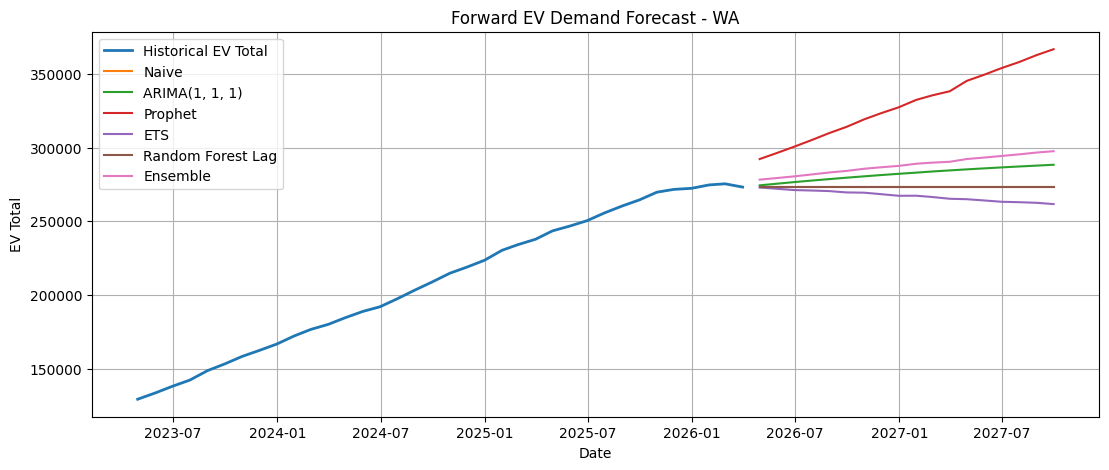

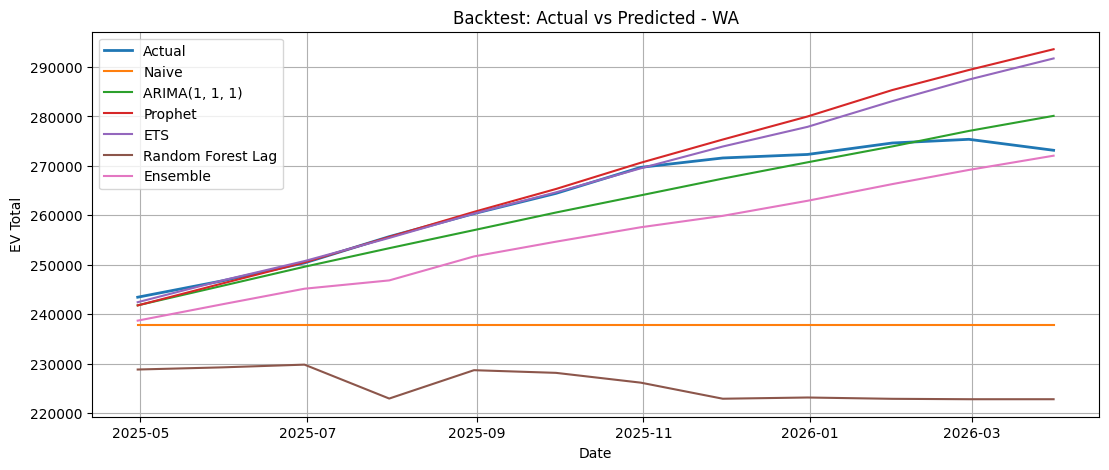

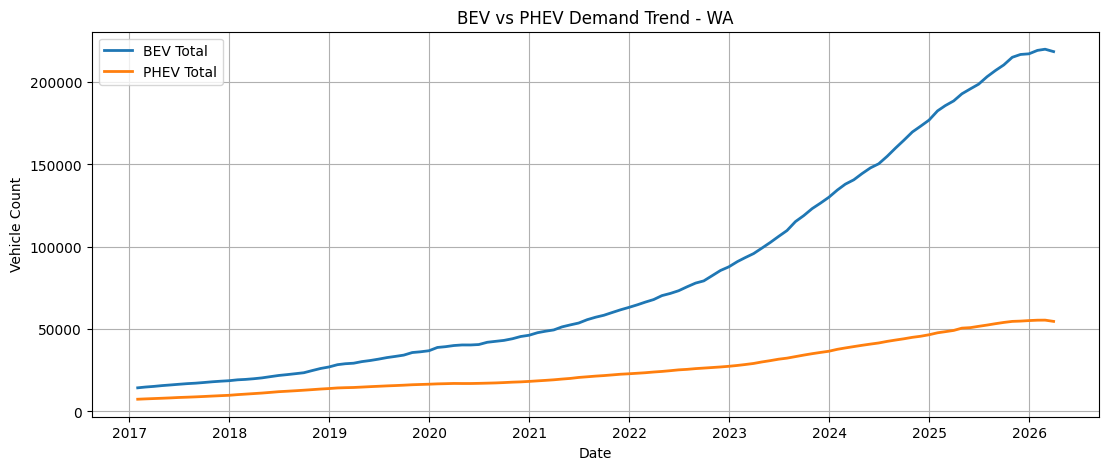

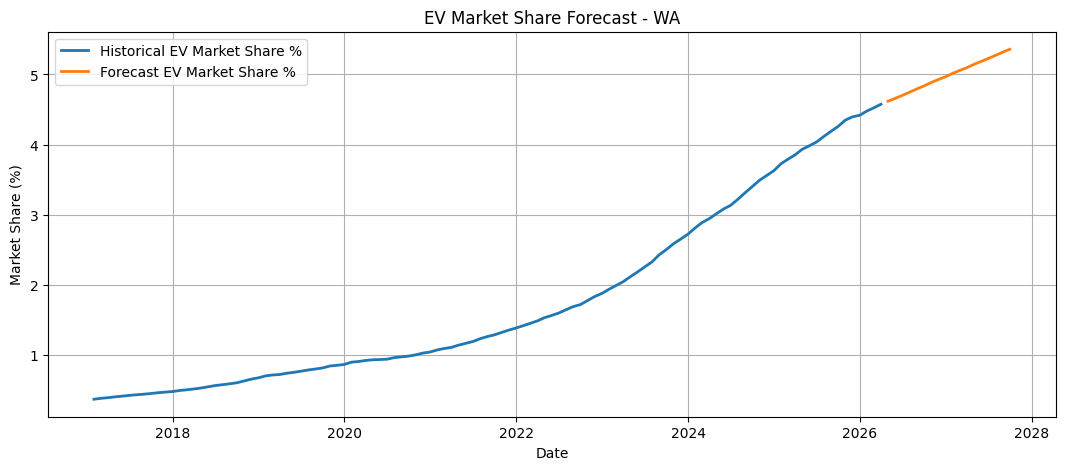

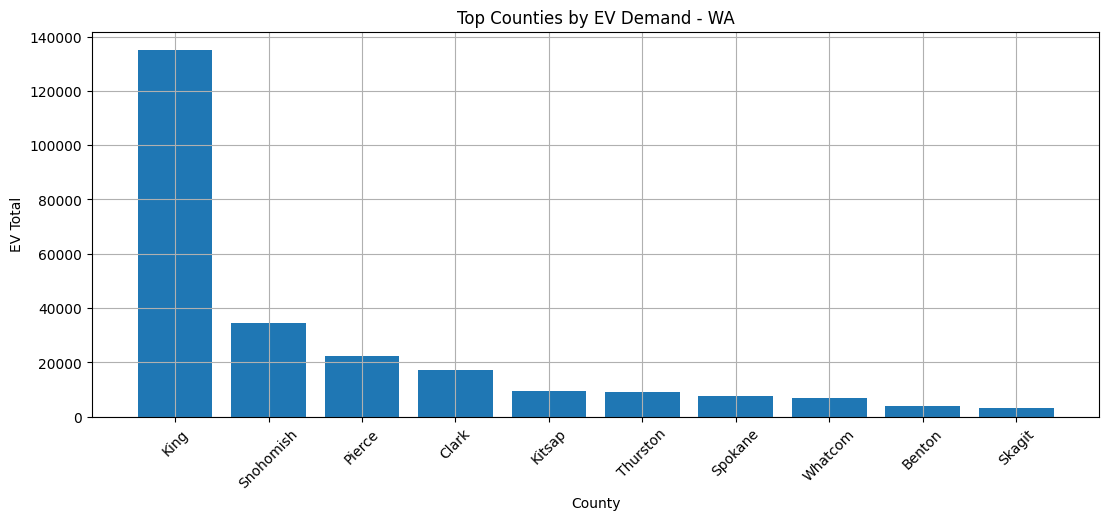

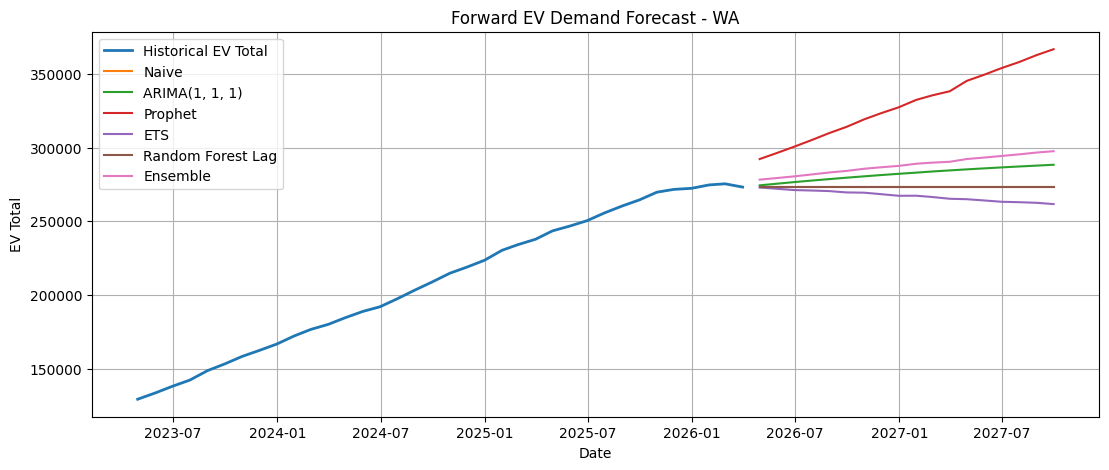

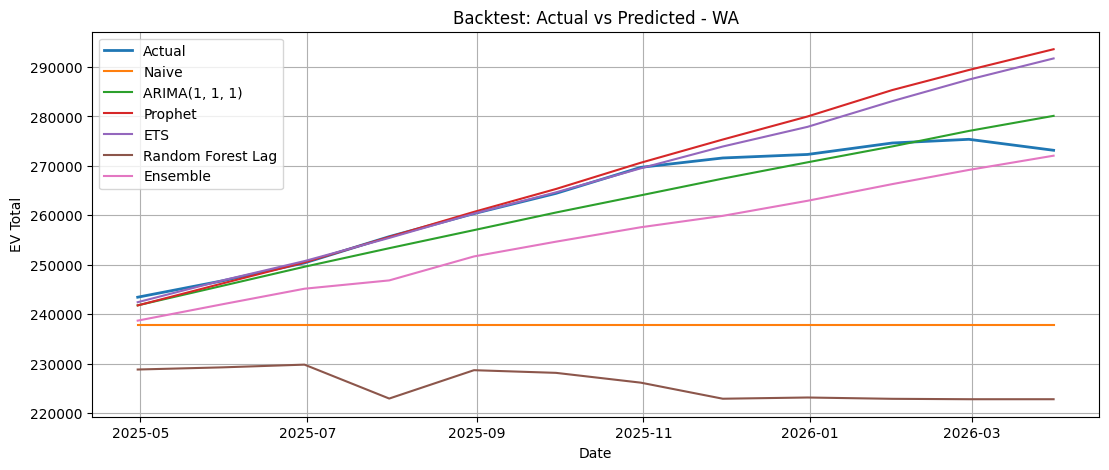

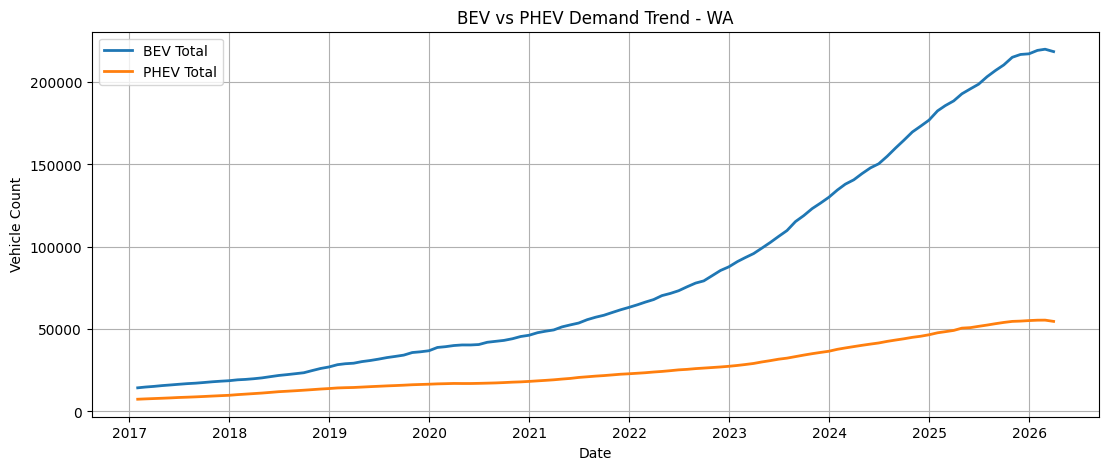

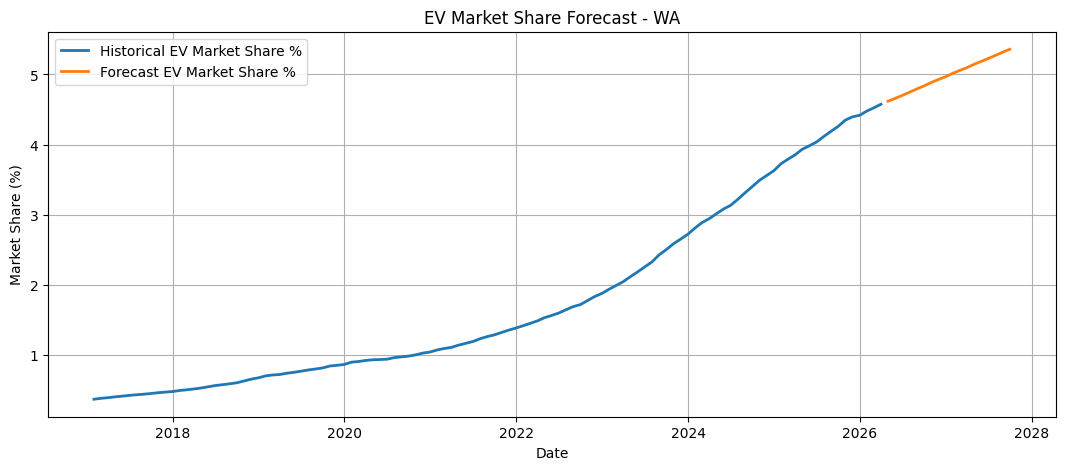

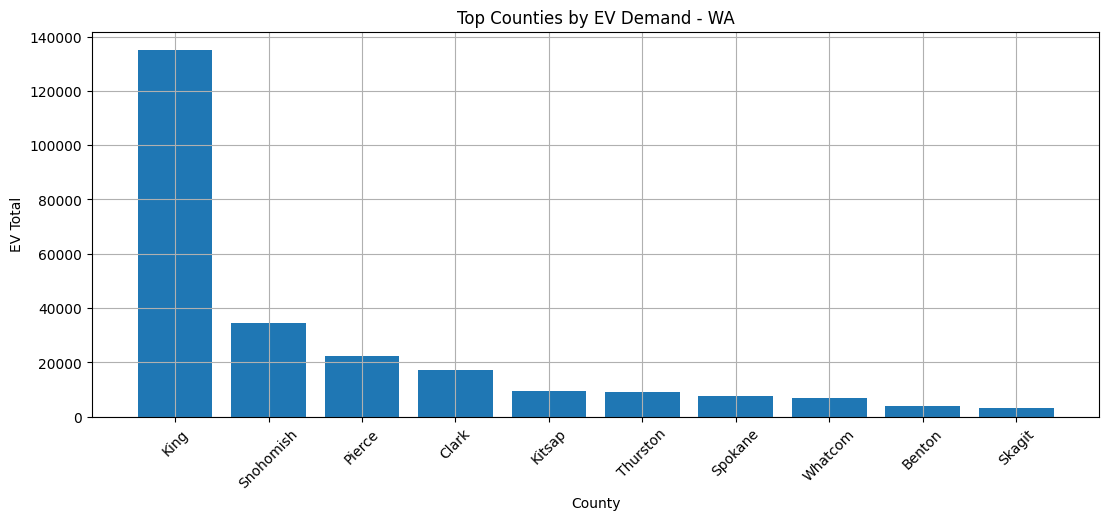

In [ ]:
# # Quick Start: Single State Forecast

# result_wa = analyze_ev_forecast_by_state(
#     state="WA",
#     horizon=18,
#     test_periods=12,
#     show_plots=True
# )

# **Uncomment the Below Cells for CHATBOT in COLAB**

In [ ]:
# # Quick Start: Notebook ChatBot

# run_ev_chatbot(default_horizon=18)

EV Demand Forecasting ChatBot
Type 'help' for commands or 'quit' to stop.

EV Bot > topcounties WA

   County  EV Total
     King    135008
Snohomish     34643
   Pierce     22453
    Clark     17123
   Kitsap      9291
 Thurston      8992
  Spokane      7721
  Whatcom      6743
   Benton      3960
   Skagit      3110

EV Bot > Which state has the strongest EV growth potential?

Based solely on the provided 18-month forecast analytics, the state with the strongest EV growth potential is **Nevada (NV)**. Here is a detailed analysis considering the key forecast metrics:

### 1. Demand Size and Current Market Context
- **Nevada's latest EV total:** 18, relatively low absolute current EV penetration compared to large states like Washington (WA) with 273,152 EVs.
- However, Nevada’s EV market share stands at **3.53%**, which is competitive given the base and indicates a solid foothold.

### 2. Growth Rate and Category
- **Nevada's forecasted EV total:** 21.03.
- **Forecast growth rate:** +1